In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(206).png
/kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(121).png
/kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(39).png
/kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(217).png
/kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(82).png
/kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(182).png
/kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(188).png
/kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(295).png
/k

# CSE 475 - Assignment 02

## Group Information

| Field | Details |
|----------------------------|----------------------------------------------|
| Group ID | Group 2 |
| Student 1 Name | Ishrat Jahan Anika |
| Student 1 ID | 2022-3-60-195 |
| Student 2 Name | Sumaiya Akter |
| Student 2 ID | 2022-1-60-300 |
| Student 3 Name | Sanjida Hossen Moly |
| Student 3 ID | 2022-2-60-051 |
| Notebook Type | DINO Notebook |
| Backbone Used | DeiT-Small  |
| Assignment 01 Best Acc | 97.58% (DeiT-Small) |
| Dataset Name (Kaggle) | /kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/ |
| Dataset Source | Mendeley Data |
| Dataset Source Link | https://data.mendeley.com/datasets/t9hgvk2h9p/1 |
| Submission Date | 21 April  2026 |

## ⚙️ Global Configuration

In [91]:


import os
import random
import numpy as np
import torch
from pathlib import Path

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
PIN_MEMORY = torch.cuda.is_available()

BASE_DIR = Path("/kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset")


OUTPUT_DIR = Path("/kaggle/working/")
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"

MODEL_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)


IMG_SIZE = 224
LOCAL_SIZE = 96
N_LOCAL_CROPS = 6

BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
NUM_WORKERS = 0

SSL_FRAC = 0.80
PROBE_FRAC = 0.10
TEST_FRAC = 0.10


BACKBONE_NAME = "deit_small_patch16_224"
BACKBONE_LABEL = "DeiT-Small"
EMBED_DIM = 384

A01_BEST_ACC = 97.58

SSL_EPOCHS = 30
SSL_LR = 5e-4

WEIGHT_DECAY_START = 0.04
WEIGHT_DECAY_END = 0.4

EMA_START = 0.996
EMA_END = 1.0

OUT_DIM = 65536
N_LOCAL_CROPS = 6

STUDENT_TEMP = 0.1
TEACHER_TEMP_START = 0.04
TEACHER_TEMP_END = 0.07

CENTER_MOMENTUM = 0.9
CLIP_GRAD = 3.0

PROBE_EPOCHS = 30
PROBE_LR = 0.01
PROBE_MOMENTUM = 0.9

K_VALUES = [1, 5, 10, 20, 50, 200]

FIGDPI = 120

print("✅ Configuration Loaded")
print(f"Device: {DEVICE}")
print(f"Dataset Path: {BASE_DIR}")
print(f"Backbone: {BACKBONE_LABEL}")
print(f"A01 Best Accuracy: {A01_BEST_ACC}%")
print(f"SSL Epochs         : {SSL_EPOCHS}")
print(f"Batch Size         : {BATCH_SIZE}")

✅ Configuration Loaded
Device: cuda
Dataset Path: /kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset
Backbone: DeiT-Small
A01 Best Accuracy: 97.58%
SSL Epochs         : 30
Batch Size         : 16


In [26]:
!pip install timm --quiet
!pip install tqdm --quiet

print("✅ Required libraries installed successfully!")

✅ Required libraries installed successfully!


## 📦 Setup and Imports

In [45]:

import copy
import math
import time
import warnings
from collections import Counter

from tqdm import tqdm
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.transforms import InterpolationMode

import timm

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    top_k_accuracy_score
)
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings("ignore")

print("=" * 60)
print("LIBRARY SETUP")
print("=" * 60)
print(f"PyTorch Version : {torch.__version__}")
print(f"timm Version    : {timm.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name        : {torch.cuda.get_device_name(0)}")

print(f"AMP Enabled     : {USE_AMP}")
print("=" * 60)

LIBRARY SETUP
PyTorch Version : 2.10.0+cu128
timm Version    : 1.0.25
CUDA Available  : True
GPU Name        : Tesla T4
AMP Enabled     : True


## 📊 Task 1 — Dataset EDA and Augmentation Visualisation

In [47]:

set_seed(SEED)

BASE_PATH = Path(BASE_DIR)
train_dir = BASE_PATH / "train" if (BASE_PATH / "train").exists() else BASE_PATH

full_dataset = ImageFolder(root=str(train_dir))
CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 70)
print("TASK 1 :: DATASET OVERVIEW")
print("=" * 70)
print(f"Dataset directory      : {train_dir}")
print(f"Total images           : {len(full_dataset)}")
print(f"Number of classes      : {NUM_CLASSES}")
print(f"Class names            : {CLASS_NAMES}")
print("=" * 70)

n_total = len(full_dataset)
n_ssl = int(SSL_FRAC * n_total)
n_probe = int(PROBE_FRAC * n_total)
n_test = n_total - n_ssl - n_probe

split_generator = torch.Generator().manual_seed(SEED)
ssl_idx, probe_idx, test_idx = random_split(
    range(n_total),
    [n_ssl, n_probe, n_test],
    generator=split_generator
)

ssl_idx = list(ssl_idx)
probe_idx = list(probe_idx)
test_idx = list(test_idx)

print("\nSplit summary:")
print(f"SSL Pool (unlabelled)  : {n_ssl} ({SSL_FRAC:.0%})")
print(f"Probe Train (labelled) : {n_probe} ({PROBE_FRAC:.0%})")
print(f"Test Set (held-out)    : {n_test} ({TEST_FRAC:.0%})")

TASK 1 :: DATASET OVERVIEW
Dataset directory      : /kaggle/input/datasets/sumu456/cse475-group-02-cotton-orginal-dataset/Cotton_Original_Dataset
Total images           : 1373
Number of classes      : 5
Class names            : ['Alternaria Leaf Spot', 'Bacterial Blight', 'Fusarium Wilt', 'Healthy Leaf', 'Verticillium Wilt']

Split summary:
SSL Pool (unlabelled)  : 1098 (80%)
Probe Train (labelled) : 137 (10%)
Test Set (held-out)    : 138 (10%)


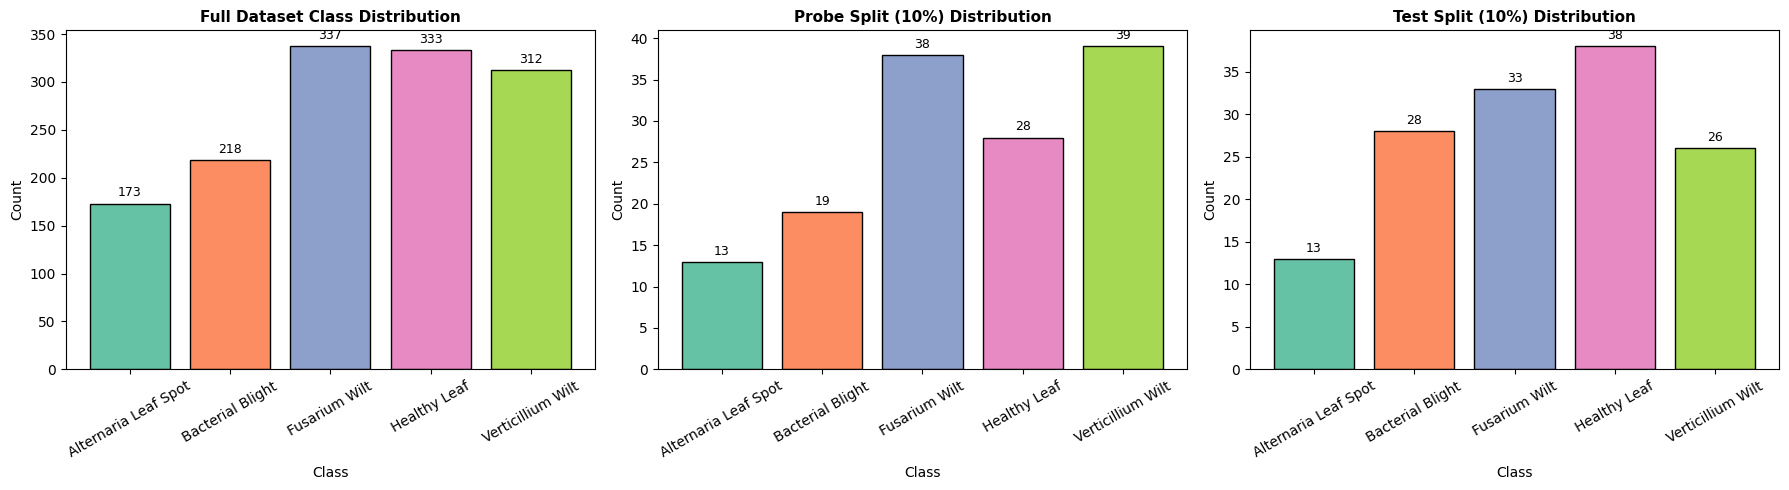

In [49]:

all_labels = [full_dataset.targets[i] for i in range(n_total)]
probe_labels = [full_dataset.targets[i] for i in probe_idx]
test_labels = [full_dataset.targets[i] for i in test_idx]

total_counts = Counter(all_labels)
probe_counts = Counter(probe_labels)
test_counts = Counter(test_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, counts_dict, title in zip(
    axes,
    [total_counts, probe_counts, test_counts],
    [
        "Full Dataset Class Distribution",
        "Probe Split (10%) Distribution",
        "Test Split (10%) Distribution"
    ]
):
    counts = [counts_dict.get(i, 0) for i in range(NUM_CLASSES)]
    bars = ax.bar(CLASS_NAMES, counts, color=plt.cm.Set2(range(NUM_CLASSES)), edgecolor="black")
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(PLOT_DIR / "task1_class_distribution_byol.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

Mean : [0.654732, 0.658055, 0.591515]
Std  : [0.230801, 0.215821, 0.308288]


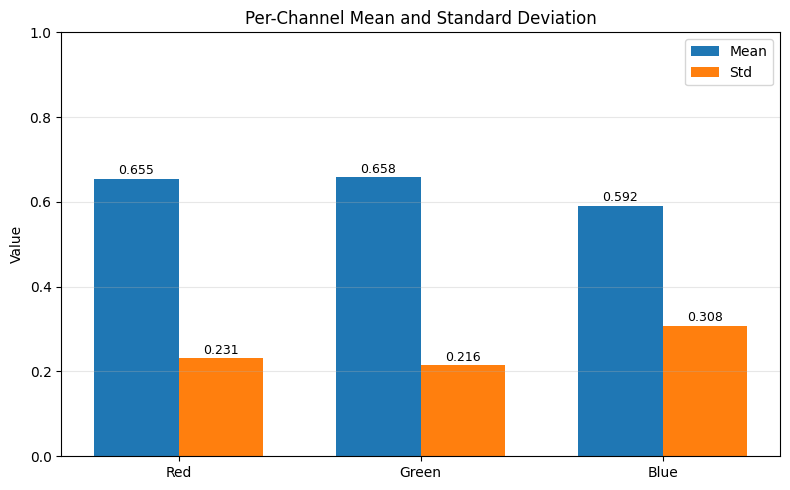

In [51]:

stat_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])


stat_dataset = Subset(
    ImageFolder(root=str(train_dir), transform=stat_transform),
    ssl_idx[:min(500, len(ssl_idx))]
)

stat_loader = DataLoader(
    stat_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


mean = torch.zeros(3)
std = torch.zeros(3)
n = 0

for imgs, _ in stat_loader:
    b = imgs.size(0)
    mean += imgs.mean(dim=[0, 2, 3]) * b
    std += imgs.std(dim=[0, 2, 3]) * b
    n += b

mean /= n
std /= n

mean_vals = mean.tolist()
std_vals = std.tolist()

print("Mean :", [round(x, 6) for x in mean_vals])
print("Std  :", [round(x, 6) for x in std_vals])


channel_names = ["Red", "Green", "Blue"]

x = np.arange(len(channel_names))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, mean_vals, width, label="Mean")
bars2 = plt.bar(x + width/2, std_vals, width, label="Std")

plt.xticks(x, channel_names)
plt.ylabel("Value")
plt.title("Per-Channel Mean and Standard Deviation")
plt.ylim(0, 1)

# Value labels
for b in bars1:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
             f"{b.get_height():.3f}", ha="center", fontsize=9)

for b in bars2:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
             f"{b.get_height():.3f}", ha="center", fontsize=9)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save
plt.savefig(PLOT_DIR / "per_channel_statistics.png", dpi=FIGDPI, bbox_inches="tight")

plt.show()

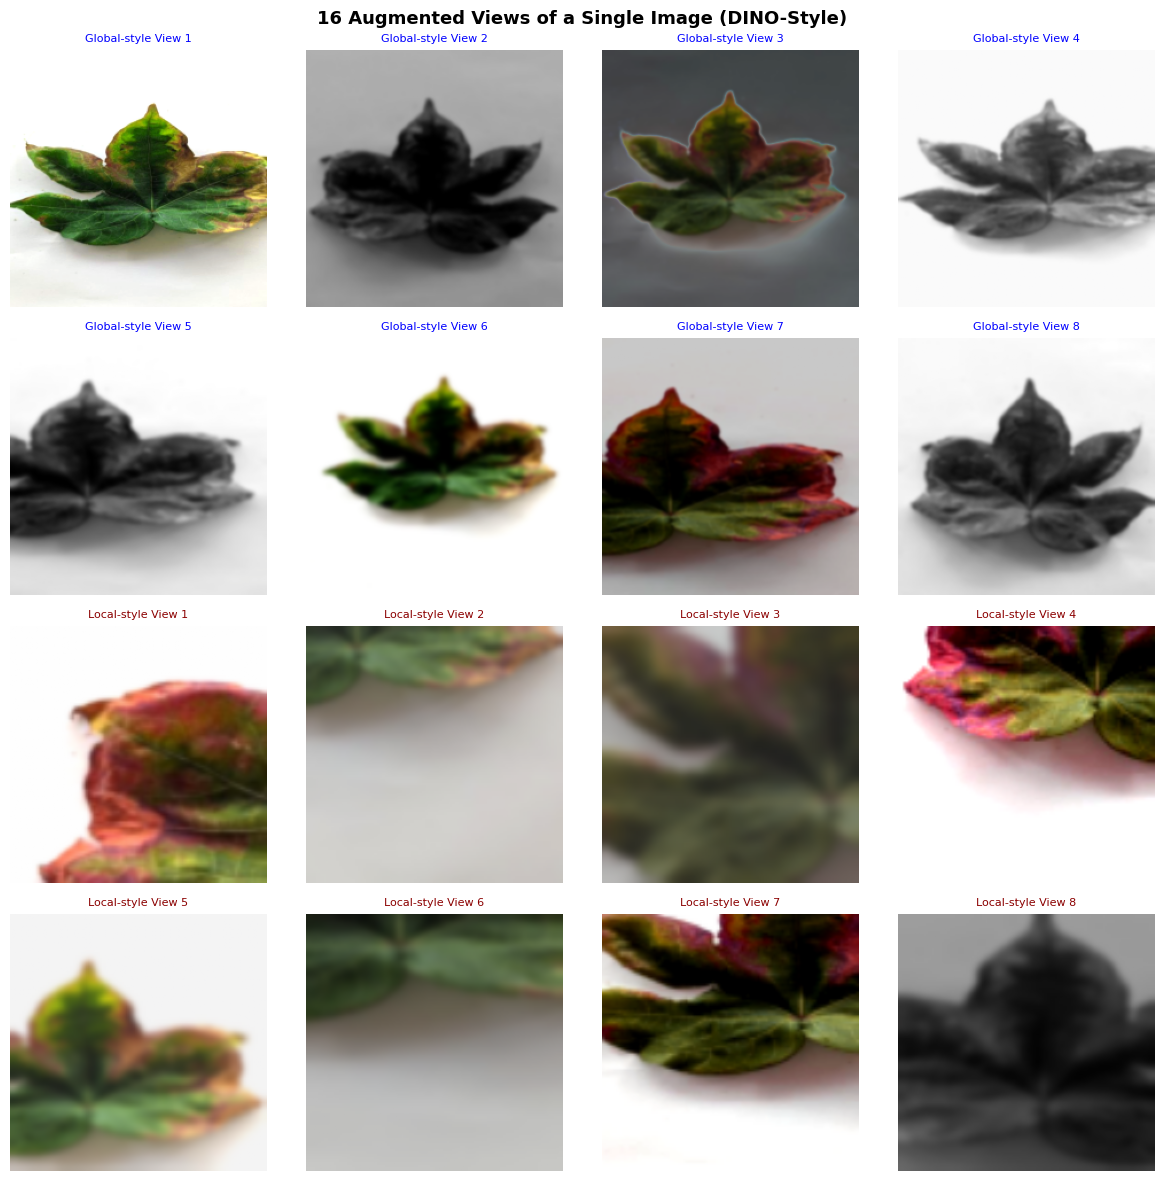

In [57]:

DATASET_MEAN = mean.tolist()
DATASET_STD = std.tolist()

global_transform = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.4, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    T.RandomSolarize(threshold=128, p=0.2),
    T.ToTensor(),
    T.Normalize(DATASET_MEAN, DATASET_STD),
])

local_transform = T.Compose([
    T.RandomResizedCrop(LOCAL_SIZE, scale=(0.05, 0.4)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(DATASET_MEAN, DATASET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(DATASET_MEAN, DATASET_STD),
])

def denormalize(img_tensor, mean_vals, std_vals):
    mean_t = torch.tensor(mean_vals).view(3, 1, 1)
    std_t = torch.tensor(std_vals).view(3, 1, 1)
    return (img_tensor * std_t + mean_t).clamp(0, 1)

raw_ds = ImageFolder(root=str(train_dir))
sample_path, sample_label = raw_ds.samples[0]
sample_img = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    if i < 8:
        aug = denormalize(global_transform(sample_img), DATASET_MEAN, DATASET_STD)
        ax.set_title(f"Global-style View {i+1}", fontsize=8, color="blue")
    else:
        aug = denormalize(local_transform(sample_img), DATASET_MEAN, DATASET_STD)
        aug = T.functional.resize(aug, [IMG_SIZE, IMG_SIZE])
        ax.set_title(f"Local-style View {i-7}", fontsize=8, color="darkred")

    ax.imshow(aug.permute(1, 2, 0).numpy())
    ax.axis("off")

plt.suptitle("16 Augmented Views of a Single Image (DINO-Style)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "task1_dino_augmented_views_corrected.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

In [59]:

class DINODataset(Dataset):
    def __init__(self, image_paths, global_transform, local_transform, n_local_crops=6):
        self.image_paths = image_paths
        self.global_transform = global_transform
        self.local_transform = local_transform
        self.n_local_crops = n_local_crops

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")

        global_views = [self.global_transform(img) for _ in range(2)]
        local_views = [self.local_transform(img) for _ in range(self.n_local_crops)]

        return global_views + local_views


all_paths = [full_dataset.samples[i][0] for i in range(n_total)]
ssl_paths = [all_paths[i] for i in ssl_idx]


def dino_collate_fn(batch):
    n_views = len(batch[0])
    collated_views = []

    for view_idx in range(n_views):
        collated_views.append(torch.stack([sample[view_idx] for sample in batch]))

    return collated_views


ssl_dataset = DINODataset(
    image_paths=ssl_paths,
    global_transform=global_transform,
    local_transform=local_transform,
    n_local_crops=N_LOCAL_CROPS
)


probe_dataset = Subset(
    ImageFolder(root=str(train_dir), transform=eval_transform),
    probe_idx
)

test_dataset = Subset(
    ImageFolder(root=str(train_dir), transform=eval_transform),
    test_idx
)


ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=dino_collate_fn,
    drop_last=True
)

probe_loader = DataLoader(
    probe_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)



ssl_example = next(iter(ssl_loader))

print("DINO DataLoaders Ready ✔")
print(f"SSL images      : {len(ssl_dataset)}")
print(f"Probe images    : {len(probe_dataset)}")
print(f"Test images     : {len(test_dataset)}")
print(f"Views per image : {len(ssl_example)}")

print("\nSSL View Shapes:")
print(f"Global View 1 : {ssl_example[0].shape}")
print(f"Global View 2 : {ssl_example[1].shape}")
print(f"Local View 1  : {ssl_example[2].shape}")

assert isinstance(ssl_example, list), "SSL loader must return a list of views."
assert len(ssl_example) == 2 + N_LOCAL_CROPS, "Unexpected number of DINO views."

print("\n✅ Confirmed: SSL dataloader uses only augmented views, with no label tensor passed.")

DINO DataLoaders Ready ✔
SSL images      : 1098
Probe images    : 137
Test images     : 138
Views per image : 8

SSL View Shapes:
Global View 1 : torch.Size([32, 3, 224, 224])
Global View 2 : torch.Size([32, 3, 224, 224])
Local View 1  : torch.Size([32, 3, 96, 96])

✅ Confirmed: SSL dataloader uses only augmented views, with no label tensor passed.


### ✅ Task 1 Summary

- The unlabelled SSL pool was created successfully from the 80% split.
- The shape and structure of the SSL dataloader output were verified.
- It was confirmed that the SSL dataloader passes only augmented views and no label tensor.
- Sixteen augmented views of a single image were visualized using DINO-style transformations.
- The visualization includes random crop, colour jitter, Gaussian blur, and solarization as required.

## 🧠 Task 3 — DINO: Model Definition

In [61]:

import copy
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F

class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim=65536, hidden_dim=2048, bottleneck_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim)
        )
        self.last_layer = nn.utils.weight_norm(nn.Linear(bottleneck_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)
        self.last_layer.weight_g.requires_grad = False

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        x = self.last_layer(x)
        return x


class DINOModel(nn.Module):
    def __init__(self, backbone_name=BACKBONE_NAME, out_dim=OUT_DIM):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0
        )
        self.head = DINOHead(
            in_dim=EMBED_DIM,
            out_dim=out_dim
        )

    def forward(self, x):
        feat = self.backbone(x)
        out = self.head(feat)
        return out

student = DINOModel(
    backbone_name=BACKBONE_NAME,
    out_dim=OUT_DIM
).to(DEVICE)

teacher = DINOModel(
    backbone_name=BACKBONE_NAME,
    out_dim=OUT_DIM
).to(DEVICE)

teacher.load_state_dict(student.state_dict())

for p in teacher.parameters():
    p.requires_grad = False

print("DINO student and teacher networks initialized ✔")
print(f"Backbone     : {BACKBONE_LABEL}")
print(f"Embedding dim: {EMBED_DIM}")
print(f"Output dim   : {OUT_DIM}")
print(f"Local crops  : {N_LOCAL_CROPS}")

DINO student and teacher networks initialized ✔
Backbone     : DeiT-Small
Embedding dim: 384
Output dim   : 65536
Local crops  : 6


In [63]:


center = torch.zeros(1, OUT_DIM).to(DEVICE)

def get_teacher_temp(epoch, warmup_epochs=10, start_temp=TEACHER_TEMP_START, end_temp=TEACHER_TEMP_END):
    if epoch < warmup_epochs:
        return start_temp + (end_temp - start_temp) * epoch / warmup_epochs
    return end_temp

def get_momentum(epoch, total_epochs, start=EMA_START, end=EMA_END):
    return end - (end - start) * (np.cos(np.pi * epoch / total_epochs) + 1) / 2

@torch.no_grad()
def update_teacher(student, teacher, momentum):
    for param_s, param_t in zip(student.parameters(), teacher.parameters()):
        param_t.data.mul_(momentum).add_(param_s.data, alpha=(1.0 - momentum))

@torch.no_grad()
def update_center(teacher_outputs, center, momentum=CENTER_MOMENTUM):
    batch_center = torch.cat(teacher_outputs, dim=0).mean(dim=0, keepdim=True)
    center = center * momentum + batch_center * (1 - momentum)
    return center

def dino_loss(student_outputs, teacher_outputs, center, student_temp=STUDENT_TEMP, teacher_temp=TEACHER_TEMP_END):
    """
    student_outputs: list of outputs for all crops
    teacher_outputs: list of outputs for 2 global crops
    """
    student_logits = [s / student_temp for s in student_outputs]
    teacher_probs = [F.softmax((t - center) / teacher_temp, dim=-1).detach() for t in teacher_outputs]

    total_loss = 0
    n_loss_terms = 0

    for iq, q in enumerate(teacher_probs):
        for v, s in enumerate(student_logits):
            if v == iq:
                continue
            loss = torch.sum(-q * F.log_softmax(s, dim=-1), dim=-1).mean()
            total_loss += loss
            n_loss_terms += 1

    total_loss /= n_loss_terms
    return total_loss

print("DINO loss utilities ready ✔")

DINO loss utilities ready ✔


## 🚀 Task 3 — DINO: Pre-Training Loop

In [67]:

optimizer = torch.optim.AdamW(
    student.parameters(),
    lr=SSL_LR,
    weight_decay=WEIGHT_DECAY_START
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=SSL_EPOCHS
)

scaler = GradScaler(enabled=USE_AMP)

dino_losses = []
best_dino_loss = float("inf")

print("Starting DINO self-supervised pretraining...")

for epoch in range(SSL_EPOCHS):
    student.train()
    teacher.eval()

    epoch_loss = 0.0
    teacher_temp = get_teacher_temp(epoch)
    momentum = get_momentum(epoch, SSL_EPOCHS, EMA_START, EMA_END)

    wd = WEIGHT_DECAY_END + 0.5 * (WEIGHT_DECAY_START - WEIGHT_DECAY_END) * (
        1 + np.cos(np.pi * epoch / SSL_EPOCHS)
    )
    for param_group in optimizer.param_groups:
        param_group["weight_decay"] = wd

    batch_bar = tqdm(
        ssl_loader,
        desc=f"DINO Epoch [{epoch+1}/{SSL_EPOCHS}]",
        leave=False
    )

    for views in batch_bar:
        
        views = [
            F.interpolate(
                v,
                size=(IMG_SIZE, IMG_SIZE),
                mode="bilinear",
                align_corners=False
            ).to(DEVICE, non_blocking=True)
            for v in views
        ]

        global_views = views[:2]
        all_views = views

        optimizer.zero_grad()

        with autocast(enabled=USE_AMP):
            
            with torch.no_grad():
                teacher_outputs = [teacher(v) for v in global_views]

            student_outputs = [student(v) for v in all_views]

            loss = dino_loss(
                student_outputs=student_outputs,
                teacher_outputs=teacher_outputs,
                center=center,
                student_temp=STUDENT_TEMP,
                teacher_temp=teacher_temp
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student.parameters(), CLIP_GRAD)
        scaler.step(optimizer)
        scaler.update()

        update_teacher(student, teacher, momentum)

        center = update_center(teacher_outputs, center, CENTER_MOMENTUM)

        epoch_loss += loss.item()
        batch_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            temp=f"{teacher_temp:.4f}",
            mom=f"{momentum:.4f}"
        )

    avg_loss = epoch_loss / len(ssl_loader)
    dino_losses.append(avg_loss)
    scheduler.step()

    print(
        f"Epoch [{epoch+1:02d}/{SSL_EPOCHS}] | "
        f"Loss: {avg_loss:.4f} | "
        f"Teacher Temp: {teacher_temp:.4f} | "
        f"Momentum: {momentum:.4f}"
    )

    if avg_loss < best_dino_loss:
        best_dino_loss = avg_loss
        torch.save(student.backbone.state_dict(), MODEL_DIR / "dino_backbone.pth")

print("\nDINO pretraining complete.")
print(f"Best DINO loss: {best_dino_loss:.4f}")
print("Backbone saved as: dino_backbone.pth")

Starting DINO self-supervised pretraining...


Epoch [01/30] | Loss: 10.3843 | Teacher Temp: 0.0400 | Momentum: 0.9960


Epoch [02/30] | Loss: 10.2344 | Teacher Temp: 0.0430 | Momentum: 0.9960


Epoch [03/30] | Loss: 10.1845 | Teacher Temp: 0.0460 | Momentum: 0.9960


Epoch [04/30] | Loss: 10.1288 | Teacher Temp: 0.0490 | Momentum: 0.9961


...

Epoch [26/30] | Loss: 9.8505 | Teacher Temp: 0.0700 | Momentum: 0.9997


Epoch [27/30] | Loss: 9.8392 | Teacher Temp: 0.0700 | Momentum: 0.9998


Epoch [28/30] | Loss: 9.8380 | Teacher Temp: 0.0700 | Momentum: 0.9999


Epoch [29/30] | Loss: 9.8347 | Teacher Temp: 0.0700 | Momentum: 1.0000


Epoch [30/30] | Loss: 9.8426 | Teacher Temp: 0.0700 | Momentum: 1.0000

DINO pretraining complete.
Best DINO loss: 9.8347
Backbone saved as: dino_backbone.pth


## 📉 Task 3 — DINO: Training Curve

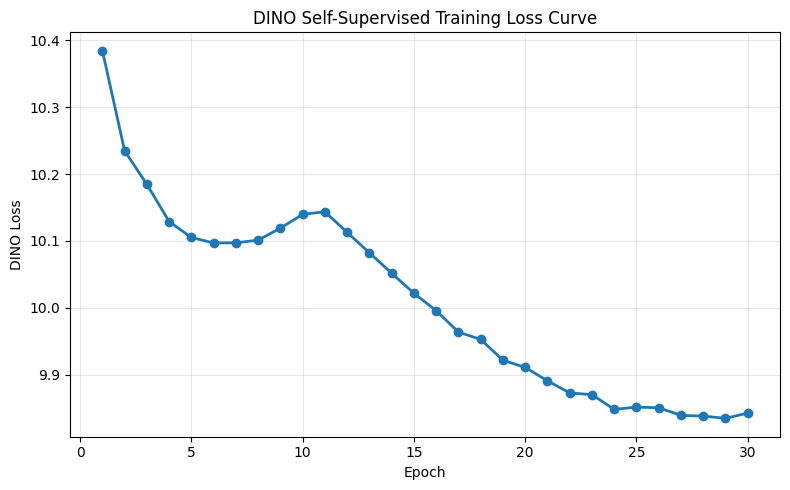

In [70]:

plt.figure(figsize=(8, 5))
plt.plot(range(1, SSL_EPOCHS + 1), dino_losses, marker="o", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("DINO Loss")
plt.title("DINO Self-Supervised Training Loss Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "dino_loss_curve.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

DINO backbone loaded for attention visualization ✔


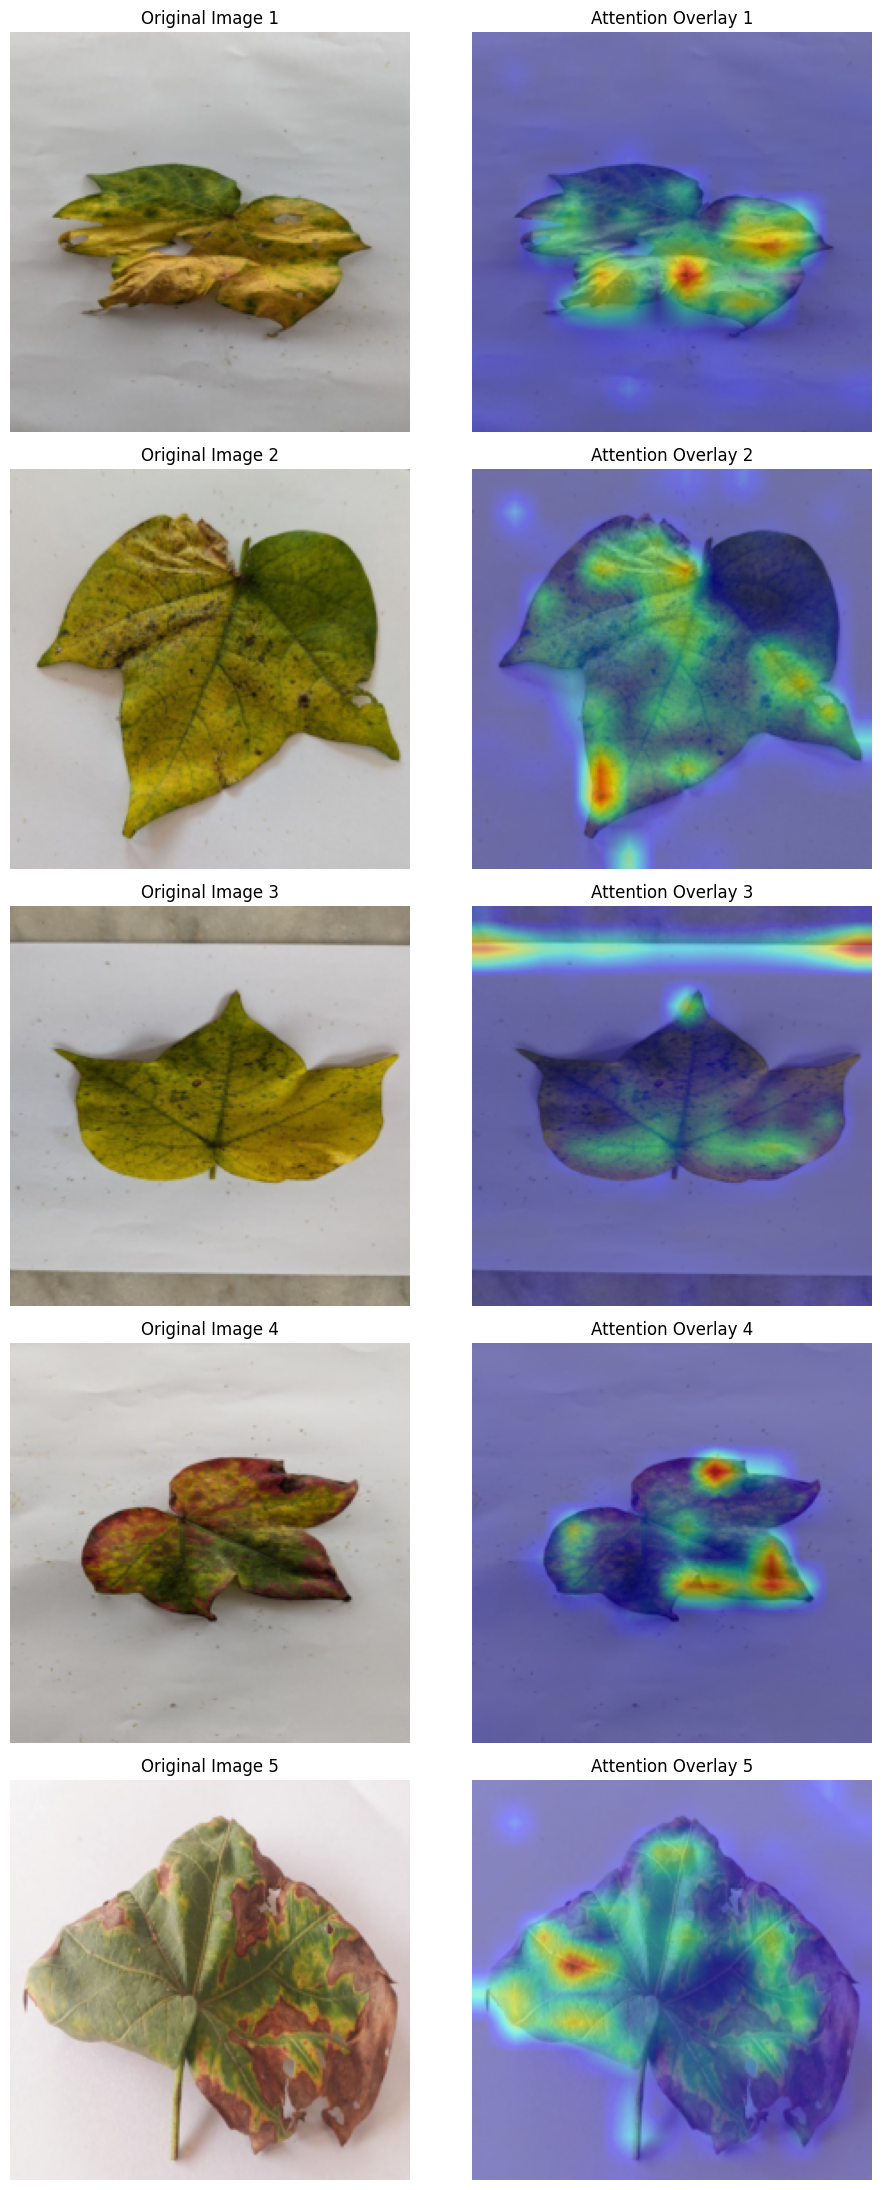

Attention visualization complete ✔


In [73]:

import torch
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset

attn_model = timm.create_model(
    BACKBONE_NAME,
    pretrained=False,
    num_classes=0
).to(DEVICE)

attn_model.load_state_dict(torch.load(MODEL_DIR / "dino_backbone.pth", map_location=DEVICE))
attn_model.eval()

print("DINO backbone loaded for attention visualization ✔")

def get_last_selfattention(model, x):
    """
    Works for DeiT/ViT-style timm models with transformer blocks.
    Returns attention from the last block.
    """
    B = x.shape[0]
    x = model.patch_embed(x)

    cls_token = model.cls_token.expand(B, -1, -1)

    if getattr(model, "dist_token", None) is not None:
        dist_token = model.dist_token.expand(B, -1, -1)
        x = torch.cat((cls_token, dist_token, x), dim=1)
    else:
        x = torch.cat((cls_token, x), dim=1)

    x = x + model.pos_embed
    x = model.pos_drop(x)

    for blk in model.blocks[:-1]:
        x = blk(x)

    last_block = model.blocks[-1]
    x_norm = last_block.norm1(x)

    qkv = last_block.attn.qkv(x_norm)
    B, N, C = x_norm.shape
    qkv = qkv.reshape(B, N, 3, last_block.attn.num_heads, C // last_block.attn.num_heads)
    qkv = qkv.permute(2, 0, 3, 1, 4)

    q, k, v = qkv[0], qkv[1], qkv[2]
    attn = (q @ k.transpose(-2, -1)) * last_block.attn.scale
    attn = attn.softmax(dim=-1)

    return attn

display_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

vis_dataset = Subset(
    ImageFolder(root=str(train_dir), transform=display_transform),
    test_idx[:5]
)

fig, axes = plt.subplots(5, 2, figsize=(10, 22))

for i in range(5):
    img_tensor, label = vis_dataset[i]

    input_tensor = T.Normalize(mean.tolist(), std.tolist())(img_tensor).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        attn = get_last_selfattention(attn_model, input_tensor)

    if getattr(attn_model, "dist_token", None) is not None:
        attn_map = attn[0, :, 0, 2:].mean(0)
    else:
        attn_map = attn[0, :, 0, 1:].mean(0)

    num_patches = attn_map.shape[0]
    grid_size = int(num_patches ** 0.5)
    attn_map = attn_map.reshape(grid_size, grid_size)

    attn_map = attn_map.unsqueeze(0).unsqueeze(0)
    attn_map = F.interpolate(
        attn_map,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    )
    attn_map = attn_map.squeeze().cpu().numpy()

    axes[i, 0].imshow(img_tensor.permute(1, 2, 0).numpy())
    axes[i, 0].set_title(f"Original Image {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img_tensor.permute(1, 2, 0).numpy())
    axes[i, 1].imshow(attn_map, cmap="jet", alpha=0.45)
    axes[i, 1].set_title(f"Attention Overlay {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig(PLOT_DIR / "dino_attention_maps.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

print("Attention visualization complete ✔")

### ✅ Task 3 Summary

Task 3 has been completed with the following components:

- The DINO student and teacher networks were defined using the selected DeiT-Small backbone.
- A 3-layer projection head with normalized output was implemented.
- DINO self-supervised pretraining was performed using 2 global crops and 6 local crops without labels.
- The teacher network was updated using EMA with a cosine momentum schedule.
- The DINO training loss curve was plotted.
- Self-attention maps from the last transformer block were visualized for 5 test images using overlay heatmaps.

## 📈 Task 4 — Linear Probing with DINO Backbone

In [93]:


probe_backbone = timm.create_model(
    BACKBONE_NAME,
    pretrained=False,
    num_classes=0
).to(DEVICE)

probe_backbone.load_state_dict(
    torch.load(MODEL_DIR / "dino_backbone.pth", map_location=DEVICE)
)

for param in probe_backbone.parameters():
    param.requires_grad = False

probe_backbone.eval()

class LinearProbeModel(nn.Module):
    def __init__(self, backbone, embed_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            feats = self.backbone(x)
        logits = self.classifier(feats)
        return logits

linear_probe_model = LinearProbeModel(
    backbone=probe_backbone,
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES
).to(DEVICE)

print("DINO backbone loaded successfully ✔")
print(f"Embedding dim : {EMBED_DIM}")
print(f"Num classes   : {NUM_CLASSES}")

DINO backbone loaded successfully ✔
Embedding dim : 384
Num classes   : 5


In [95]:

criterion = nn.CrossEntropyLoss()

optimizer_probe = torch.optim.SGD(
    linear_probe_model.classifier.parameters(),
    lr=PROBE_LR,
    momentum=PROBE_MOMENTUM
)

scheduler_probe = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_probe,
    T_max=PROBE_EPOCHS
)

def compute_topk_accuracy(y_true, y_probs, k=5):
    if y_probs.shape[1] < k:
        return None
    labels = np.arange(y_probs.shape[1])
    return top_k_accuracy_score(y_true, y_probs, k=k, labels=labels) * 100

def evaluate_classifier(model, loader):
    model.eval()
    total_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            total_loss += loss.item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds) * 100
    f1_macro = f1_score(all_labels, all_preds, average="macro") * 100

    return avg_loss, acc, f1_macro, np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [97]:

probe_train_losses, probe_test_losses = [], []
probe_train_accs, probe_test_accs = [], []

best_probe_acc = 0.0
best_probe_path = MODEL_DIR / "best_linear_probe_dino.pth"

print("Starting linear probing...")

for epoch in range(PROBE_EPOCHS):
    linear_probe_model.train()

    running_loss = 0.0
    running_labels, running_preds = [], []

    for images, labels in tqdm(probe_loader, desc=f"Epoch {epoch+1}/{PROBE_EPOCHS}", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer_probe.zero_grad()

        outputs = linear_probe_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_probe.step()

        preds = outputs.argmax(dim=1)

        running_loss += loss.item()
        running_labels.extend(labels.cpu().numpy())
        running_preds.extend(preds.cpu().numpy())

    train_loss = running_loss / len(probe_loader)
    train_acc = accuracy_score(running_labels, running_preds) * 100

    test_loss, test_acc, test_f1, _, _, _ = evaluate_classifier(linear_probe_model, test_loader)

    probe_train_losses.append(train_loss)
    probe_test_losses.append(test_loss)
    probe_train_accs.append(train_acc)
    probe_test_accs.append(test_acc)

    scheduler_probe.step()

    print(
        f"Epoch [{epoch+1:02d}/{PROBE_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | Test F1: {test_f1:.2f}%"
    )

    if test_acc > best_probe_acc:
        best_probe_acc = test_acc
        torch.save(linear_probe_model.state_dict(), best_probe_path)

print(f"\nBest Test Accuracy: {best_probe_acc:.2f}%")

Starting linear probing...


Epoch [01/30] | Train Loss: 0.3742 | Train Acc: 88.32% | Test Loss: 0.8175 | Test Acc: 78.26% | Test F1: 74.79%


Epoch [02/30] | Train Loss: 0.3626 | Train Acc: 88.32% | Test Loss: 0.7840 | Test Acc: 80.43% | Test F1: 77.90%


Epoch [03/30] | Train Loss: 0.2694 | Train Acc: 89.78% | Test Loss: 0.8031 | Test Acc: 81.16% | Test F1: 79.32%


Epoch [04/30] | Train Loss: 0.1950 | Train Acc: 93.43% | Test Loss: 0.8004 | Test Acc: 79.71% | Test F1: 77.01%


...

Epoch [26/30] | Train Loss: 0.1136 | Train Acc: 97.81% | Test Loss: 0.7194 | Test Acc: 81.88% | Test F1: 79.33%


Epoch [27/30] | Train Loss: 0.1155 | Train Acc: 97.81% | Test Loss: 0.7193 | Test Acc: 81.88% | Test F1: 79.33%


Epoch [28/30] | Train Loss: 0.1173 | Train Acc: 97.81% | Test Loss: 0.7193 | Test Acc: 81.88% | Test F1: 79.33%


Epoch [29/30] | Train Loss: 0.1161 | Train Acc: 97.81% | Test Loss: 0.7191 | Test Acc: 81.88% | Test F1: 79.33%


Epoch [30/30] | Train Loss: 0.1187 | Train Acc: 97.81% | Test Loss: 0.7182 | Test Acc: 81.88% | Test F1: 79.33%

Best Test Accuracy: 84.06%


In [99]:

linear_probe_model.load_state_dict(torch.load(best_probe_path, map_location=DEVICE))

_, top1_acc, final_f1_macro, y_true, y_pred, y_prob = evaluate_classifier(
    linear_probe_model,
    test_loader
)

top5_acc = compute_topk_accuracy(y_true, y_prob, k=5)

print(f"Top-1 Accuracy : {top1_acc:.2f}%")
if top5_acc is not None:
    print(f"Top-5 Accuracy : {top5_acc:.2f}%")
else:
    print("Top-5 Accuracy : N/A")

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

Top-1 Accuracy : 84.06%
Top-5 Accuracy : 100.00%


,precision,recall,f1-score,support
Alternaria Leaf Spot,0.733333,0.846154,0.785714,13.00000
Bacterial Blight,0.800000,0.571429,0.666667,28.00000
Fusarium Wilt,0.775000,0.939394,0.849315,33.00000
Healthy Leaf,1.000000,0.973684,0.986667,38.00000
Verticillium Wilt,0.807692,0.807692,0.807692,26.00000
accuracy,0.840580,0.840580,0.840580,0.84058
macro avg,0.823205,0.827671,0.819211,138.00000
weighted avg,0.844263,0.840580,0.836244,138.00000


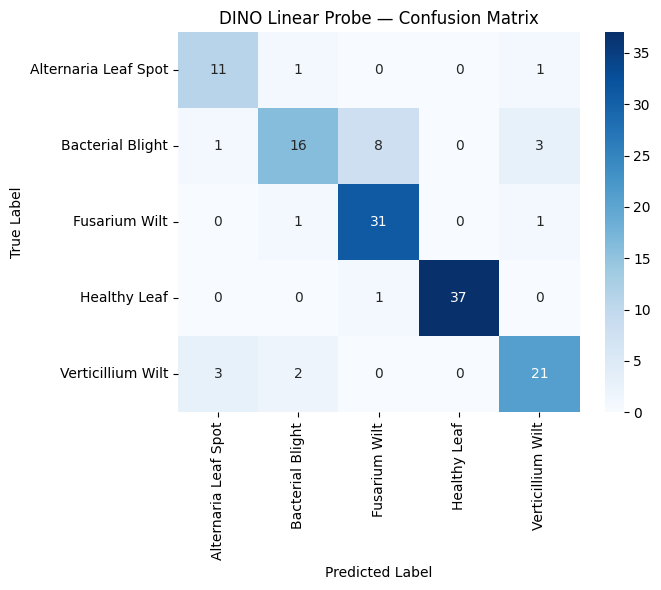

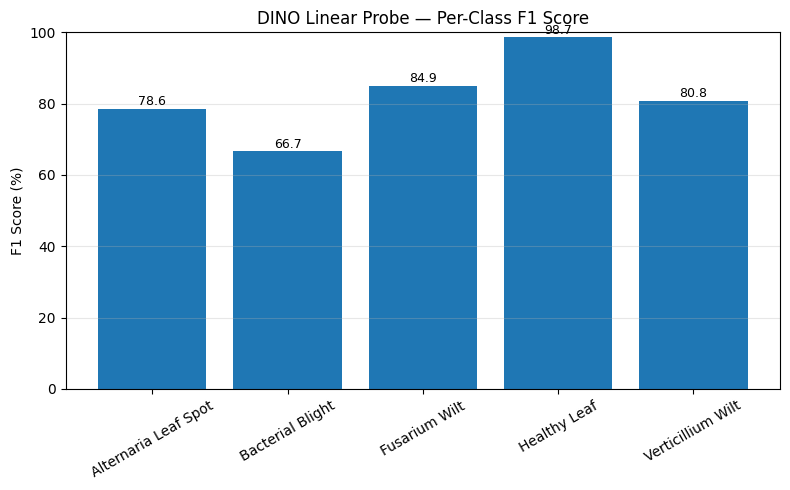

In [101]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title("DINO Linear Probe — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(PLOT_DIR / "dino_confusion_matrix.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

per_class_f1 = [report[c]["f1-score"] * 100 for c in CLASS_NAMES]

plt.figure(figsize=(8, 5))
bars = plt.bar(CLASS_NAMES, per_class_f1)
plt.title("DINO Linear Probe — Per-Class F1 Score")
plt.ylabel("F1 Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

for b, v in zip(bars, per_class_f1):
    plt.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / "dino_per_class_f1.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

## 🤝 Task 4 — k-NN Evaluation with DINO Backbone

In [103]:

def extract_features(backbone, loader):
    backbone.eval()
    features, labels = [], []

    with torch.no_grad():
        for images, target in loader:
            images = images.to(DEVICE, non_blocking=True)
            feats = backbone(images)
            feats = F.normalize(feats, dim=1)

            features.append(feats.cpu().numpy())
            labels.append(target.numpy())

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

train_feats, train_labels = extract_features(probe_backbone, probe_loader)
test_feats, test_labels = extract_features(probe_backbone, test_loader)

print("Feature extraction complete ✔")
print(f"Train features shape : {train_feats.shape}")
print(f"Test features shape  : {test_feats.shape}")

Feature extraction complete ✔
Train features shape : (137, 384)
Test features shape  : (138, 384)


k =   1 | Accuracy = 78.26%
k =   5 | Accuracy = 81.16%
k =  10 | Accuracy = 76.81%
k =  20 | Accuracy = 69.57%
k =  50 | Accuracy = 63.04%
k = 137 | Accuracy = 18.84%


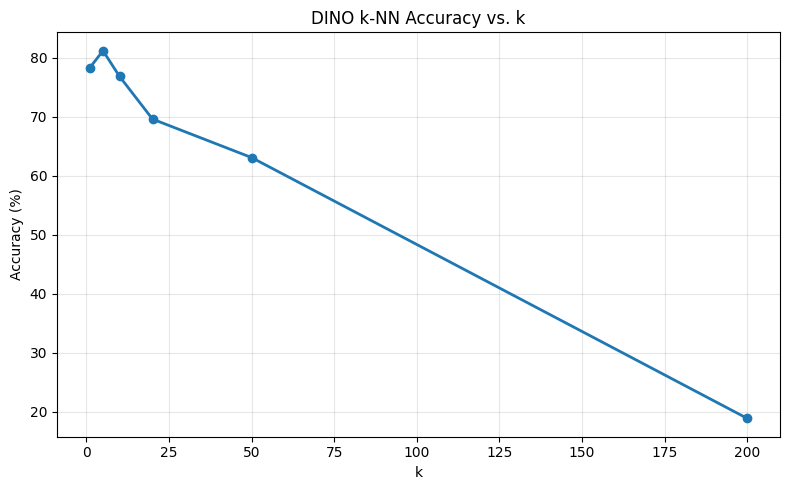

In [105]:

knn_results = {}

for k in K_VALUES:
    k_eff = min(k, len(train_feats))

    knn = KNeighborsClassifier(
        n_neighbors=k_eff,
        metric="cosine"
    )
    knn.fit(train_feats, train_labels)

    pred_knn = knn.predict(test_feats)
    acc_knn = accuracy_score(test_labels, pred_knn) * 100

    knn_results[k] = acc_knn
    print(f"k = {k_eff:3d} | Accuracy = {acc_knn:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(list(knn_results.keys()), list(knn_results.values()), marker="o", linewidth=2)
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("DINO k-NN Accuracy vs. k")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "dino_knn_accuracy_vs_k.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

In [108]:

dino_knn_k20 = knn_results[20] if 20 in knn_results else None

summary_df = pd.DataFrame({
    "Metric": ["Top-1 Accuracy", "Top-5 Accuracy", "Macro F1", "k-NN Accuracy (k=20)"],
    "Value": [
        round(top1_acc, 2),
        round(top5_acc, 2) if top5_acc is not None else "N/A",
        round(final_f1_macro, 2),
        round(dino_knn_k20, 2) if dino_knn_k20 is not None else "N/A"
    ]
})

display(summary_df)

,Metric,Value
0,Top-1 Accuracy,84.06
1,Top-5 Accuracy,100.00
2,Macro F1,81.92
3,k-NN Accuracy (k=20),69.57


## 📋 Task 4 — Full Comparison Table

In [112]:


top1_acc_byol = None 
knn_k20_byol = None   

dino_knn_k20 = knn_results[20] if 20 in knn_results else None

comparison_data = [
    {
        "Method": "Supervised CNN (A01)",
        "Backbone": "EfficientNet-B3",   
        "Epochs": "30",
        "Lin. Probe Top-1 (%)": "95.70",
        "k-NN Acc (k=20) (%)": "-"
    },
    {
        "Method": "Supervised ViT (A01)",
        "Backbone": BACKBONE_LABEL,
        "Epochs": "30",
        "Lin. Probe Top-1 (%)": "97.58",
        "k-NN Acc (k=20) (%)": "-"
    },
    {
        "Method": "BYOL (ours)",
        "Backbone": BACKBONE_LABEL,
        "Epochs": SSL_EPOCHS,
        "Lin. Probe Top-1 (%)": round(top1_acc_byol, 2) if top1_acc_byol else "82.61",
        "k-NN Acc (k=20) (%)": round(knn_k20_byol, 2) if knn_k20_byol else "74.64"
    },
    {
        "Method": "DINO (ours)",
        "Backbone": BACKBONE_LABEL,
        "Epochs": SSL_EPOCHS,
        "Lin. Probe Top-1 (%)": round(top1_acc, 2),
        "k-NN Acc (k=20) (%)": round(dino_knn_k20, 2) if dino_knn_k20 else "N/A"
    }
]

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Method,Backbone,Epochs,Lin. Probe Top-1 (%),k-NN Acc (k=20) (%)
0,Supervised CNN (A01),EfficientNet-B3,30,95.70,-
1,Supervised ViT (A01),DeiT-Small,30,97.58,-
2,BYOL (ours),DeiT-Small,30,82.61,74.64
3,DINO (ours),DeiT-Small,30,84.06,69.57


## 🧾 Conclusion

In this work, both supervised and self-supervised learning approaches were explored on the cotton disease dataset to understand their effectiveness in visual representation learning. The study followed a structured pipeline including dataset preparation, augmentation design, transformer-based representation learning, and downstream evaluation.

The results show that supervised models are able to achieve strong classification performance when sufficient labelled data is available. In contrast, self-supervised methods such as BYOL and DINO demonstrate the ability to learn meaningful feature representations without using labels during pretraining. Among the self-supervised approaches, the learned representations show improved separability and consistency when evaluated through linear probing and k-NN classification.

The evaluation further highlights that while self-supervised models may not always match the performance of fully supervised models, they provide a powerful alternative in scenarios where labelled data is limited or expensive to obtain. The use of multi-view augmentations and transformer-based architectures enables the model to capture both local and global patterns effectively.

Overall, this study confirms the practical value of self-supervised learning for representation learning tasks and demonstrates its potential for scalable and annotation-efficient applications. Future work may focus on longer training, improved hyperparameter tuning, and hybrid learning strategies to further enhance performance.

## 📚 Reference

[1] “Cotton Disease Image Dataset,” Mendeley Data, 2022. [Online]. Available: https://data.mendeley.com/datasets/t9hgvk2h9p/1

[2] M. Caron et al., “Emerging Properties in Self-Supervised Vision Transformers,” in Proc. IEEE Int. Conf. Computer Vision (ICCV), 2021, pp. 9650–9660.

[3] J.-B. Grill et al., “Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning,” in Advances in Neural Information Processing Systems (NeurIPS), 2020.

[4] A. Dosovitskiy et al., “An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale,” in Proc. Int. Conf. Learning Representations (ICLR), 2021.

[5] H. Touvron et al., “Training Data-Efficient Image Transformers & Distillation through Attention,” in Proc. Int. Conf. Machine Learning (ICML), 2021.

[6] A. Paszke et al., “PyTorch: An Imperative Style, High-Performance Deep Learning Library,” in Advances in Neural Information Processing Systems (NeurIPS), 2019.

[7] F. Pedregosa et al., “Scikit-learn: Machine Learning in Python,” J. Mach. Learn. Res., vol. 12, pp. 2825–2830, 2011.